# BigStream alignment_pipeline quick test
_Generated 2026-02-19 15:32_

This notebook loads your fixed/moving TIFF volumes and runs `alignment_pipeline`.
It is designed to be safe on memory by using tifffile memmap and an `alignment_spacing` downsample for the optimization.


In [1]:

# If running on a SLURM node, it's usually good to cap BLAS/OpenMP threads
# so you don't oversubscribe when your algorithm is already parallel.
import os
cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1))
for k in ["OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS","NUMEXPR_NUM_THREADS","ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"]:
    os.environ.setdefault(k, str(cpus))
print("CPUs:", cpus)
print({k: os.environ.get(k) for k in ["OMP_NUM_THREADS","MKL_NUM_THREADS","OPENBLAS_NUM_THREADS","ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"]})


CPUs: 14
{'OMP_NUM_THREADS': '14', 'MKL_NUM_THREADS': '14', 'OPENBLAS_NUM_THREADS': '14', 'ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS': '14'}


In [2]:

import numpy as np
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path

# ---- EDIT THESE PATHS IF NEEDED ----

MOVING_PATH = Path(
    "/Users/jonathanboulanger-weill/Harvard University Dropbox/"
    "Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/"
    "data/exp1_110425/2p_stacks/2025-10-13_16-04-47_fish002_setup1_arena0_MW_preprocessed_data_repeat00_tile000_950nm_0_flippedxz_enh.tif"
)

FIXED_PATH = Path(
    "//Users/jonathanboulanger-weill/Harvard University Dropbox/"
    "Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/"
    "data/exp1_110425/oct_confocal_stacks/fish2/prealigned/exp_001_fish2_s07_pre_GCaMP_cropped.tif"
)

out_path = Path(
    "/Users/jonathanboulanger-weill/Harvard University Dropbox/"
    "Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/"
    "Bigstream/"
)

# Global identifiers used for ALL output names
exp_id = "exp_001"     # e.g. "001" or "exp1_110425"
fish = 2           # integer

run_id = f"{exp_id}_fish{fish}"

# Spacing (microns), order: X Y Z
#FIXED_SPACING  = np.array([0.621, 0.621, 1.0], dtype=np.float64)
#MOVING_SPACING = np.array([0.396, 0.396, 2.0], dtype=np.float64)

FIXED_SPACING  = np.array([1.0, 0.621, 0.621], dtype=np.float64)
MOVING_SPACING = np.array([2.0, 0.396, 0.396], dtype=np.float64)

# For quick tests, run the optimizer on a downsampled grid (microns).
# This does NOT change your original data; it only affects the registration computation.
ALIGNMENT_SPACING = 2.0  # try 2, 4, or 8 if it is slow

print("Fixed:", FIXED_PATH)
print("Moving:", MOVING_PATH)
print("Fixed spacing:", FIXED_SPACING)
print("Moving spacing:", MOVING_SPACING)
print("Alignment spacing:", ALIGNMENT_SPACING)


Fixed: //Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/data/exp1_110425/oct_confocal_stacks/fish2/prealigned/exp_001_fish2_s07_pre_GCaMP_cropped.tif
Moving: /Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/data/exp1_110425/2p_stacks/2025-10-13_16-04-47_fish002_setup1_arena0_MW_preprocessed_data_repeat00_tile000_950nm_0_flippedxz_enh.tif
Fixed spacing: [1.    0.621 0.621]
Moving spacing: [2.    0.396 0.396]
Alignment spacing: 2.0


In [3]:

# Load volumes (memmap to avoid copying huge arrays into RAM)
fix_mm = tifffile.memmap(FIXED_PATH)
mov_mm = tifffile.memmap(MOVING_PATH)

# Convert from big-endian (e.g. >u2) to native + float32
fix = np.asarray(fix_mm).astype(np.float32, copy=False)
mov = np.asarray(mov_mm).astype(np.float32, copy=False)

print("Fixed dtype/shape:", fix.dtype, fix.shape)
print("Moving dtype/shape:", mov.dtype, mov.shape)

# Basic sanity: make sure we are in ZYX order or XYZ? Many TIFFs are Z,Y,X.
# BigStream assumes arrays are in numpy axis order (z,y,x) but spacing is given (x,y,z).
# Your code uses spacing in X,Y,Z. We'll keep that convention, but be consistent everywhere.


Fixed dtype/shape: float32 (59, 744, 591)
Moving dtype/shape: float32 (56, 799, 799)


In [4]:
import numpy as np
import nrrd
from scipy.ndimage import gaussian_filter, binary_fill_holes, binary_closing, binary_dilation
from skimage.filters import threshold_otsu
from skimage.measure import label

def save_path(tag: str, ext: str) -> Path:
    """Standard output path: <out_path>/<run_id>_<tag>.<ext>"""
    return out_path / f"{run_id}_{tag}.{ext}"

def otsu_fill_mask(vol, sigma=2, close_shape=(5,5,5), dilate_iter=64):
    # normalize
    v = vol.astype(np.float32)
    p1, p99 = np.percentile(v, (1, 99))
    v = np.clip((v - p1) / (p99 - p1 + 1e-6), 0, 1)

    # smooth
    v = gaussian_filter(v, sigma=sigma)

    # threshold
    t = threshold_otsu(v)
    m = v > t

    # keep largest CC (guard empty)
    lbl = label(m)
    if lbl.max() > 0:
        counts = np.bincount(lbl.ravel())
        counts[0] = 0
        m = lbl == counts.argmax()

    # fill + smooth + margin
    m = binary_fill_holes(m)
    m = binary_closing(m, structure=np.ones(close_shape, dtype=bool))
    m = binary_dilation(m, iterations=int(dilate_iter))

    return m.astype(np.uint8)

# --- FIX mask ---
fix_mask = otsu_fill_mask(fix, sigma=2, close_shape=(5,5,5), dilate_iter=32)
fix_mask_path = save_path("fix_mask", "nrrd")
nrrd.write(str(fix_mask_path), fix_mask)
print("  fix:", fix_mask_path)

# --- MOV mask (same strategy, homogeneous) ---
mov_mask = otsu_fill_mask(mov, sigma=2, close_shape=(5,5,5), dilate_iter=32)
mov_mask_path = save_path("mov_mask", "nrrd")
nrrd.write(str(mov_mask_path), mov_mask)
print("  mov:", mov_mask_path)

  fix: /Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/Bigstream/exp_001_fish2_fix_mask.nrrd
  mov: /Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/Bigstream/exp_001_fish2_mov_mask.nrrd


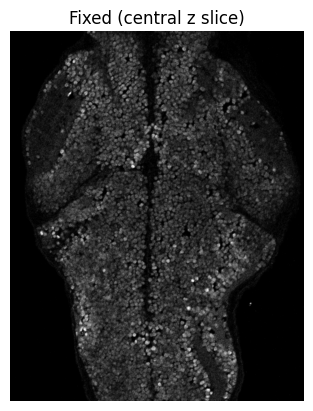

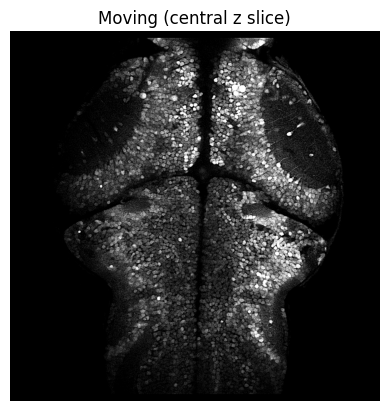

In [5]:

# Quick visualization: show central z-slice for both volumes
z_fix = fix.shape[0] // 2
z_mov = mov.shape[0] // 2

plt.figure()
plt.imshow(fix[z_fix], cmap="gray")
plt.title("Fixed (central z slice)")
plt.axis("off")
plt.show()

plt.figure()
plt.imshow(mov[z_mov], cmap="gray")
plt.title("Moving (central z slice)")
plt.axis("off")
plt.show()


In [6]:

# Import your BigStream alignment functions
# Adjust this import if your align.py lives elsewhere.
# Option A: if align.py is in the same folder as this notebook:
# from align import alignment_pipeline
#
# Option B: if it's installed as a package/module:
# from bigstream.align import alignment_pipeline  # (example; may differ)
#
# For now, assume you've saved the code you pasted into a file named `align.py` next to this notebook.

from bigstream.align import alignment_pipeline


In [ ]:
from scipy.ndimage import gaussian_filter

def downsample_with_smoothing(vol, spacing, factor=5):
    sigma = factor / 2.0  # mild pre-blur
    vol_smooth = gaussian_filter(vol, sigma=sigma)
    vol_ds = vol_smooth[::factor, ::factor, ::factor]
    spacing_ds = np.array(spacing) * factor
    return vol_ds, spacing_ds

In [ ]:

# Define a practical step schedule for an initial test.
# Start simple (ransac -> affine). Add deform once affine looks reasonable.

steps = [
    ("deform", {
        "control_point_spacing": 10,
        "control_point_levels": [4, 8, 16, 32, 64],
        "metric": "MMI",
        "metric_args": {"numberOfHistogramBins": 32},
        "optimizer": "GD",
        "optimizer_args": {"numberOfIterations": 10},
        "sampling": "NONE",
        "shrink_factors": (2,),
        "smooth_sigmas": (8.0,),
        "alignment_spacing": 2.0,
    }),
]

    ("deform", {
        "control_point_spacing": 20,
        "control_point_levels": [4, 2, 1],
        "metric": "MMI",
        "metric_args": {"numberOfHistogramBins": 32},
        "optimizer": "GD",
        "optimizer_args": {"numberOfIterations": 10},
        "sampling": "REGULAR",
        "sampling_percentage": 0.10,
        "shrink_factors": (2,),
        "smooth_sigmas": (8.0,),
        "alignment_spacing": 2.0,
    }),


In [ ]:
steps = [
    ("rigid", {
        "metric": "MMI",
        "metric_args": {"numberOfHistogramBins": 32},
        "optimizer": "RSGD",
        "optimizer_args": {
            "learningRate": 2.0,
            "minStep": 1e-4,
            "numberOfIterations": 300,
        },
        "sampling": "REGULAR",
        "sampling_percentage": 0.25,
        "shrink_factors": (4, 2, 1),
        "smooth_sigmas": (8.0, 4.0, 2.0),
        "alignment_spacing": 2.0,
        "initial_condition": "CENTER",
    }),

    ("affine", {
        "metric": "MMI",
        "metric_args": {"numberOfHistogramBins": 32},
        "optimizer": "RSGD",
        "optimizer_args": {
            "learningRate": 1.0,
            "minStep": 1e-4,
            "numberOfIterations": 400,
        },
        "sampling": "REGULAR",
        "sampling_percentage": 0.20,
        "shrink_factors": (4, 2, 1),
        "smooth_sigmas": (8.0, 4.0, 2.0),
        "alignment_spacing": 2.0,
    }),
]

In [65]:

# Run alignment pipeline
# Note: return_format='flatten' returns a single composite transform (often a displacement field if deform included).
# For inspection, try return_format='independent' first.

transform_list = alignment_pipeline(
    fix=fix,
    mov=mov,
    fix_spacing=FIXED_SPACING,
    mov_spacing=MOVING_SPACING,
    steps=steps,
    fix_mask=fix_mask,
    mov_mask=mov_mask,
    return_format="independent",
    context="TEST",
)

print("Returned", len(transform_list), "transforms")
for i, t in enumerate(transform_list):
    if isinstance(t, np.ndarray):
        print(i, "ndarray", t.shape, t.dtype)
    else:
        # deform step returns a field (ndarray) in this implementation
        print(i, type(t))


TypeError: configure_irm() got an unexpected keyword argument 'final_metric_check'

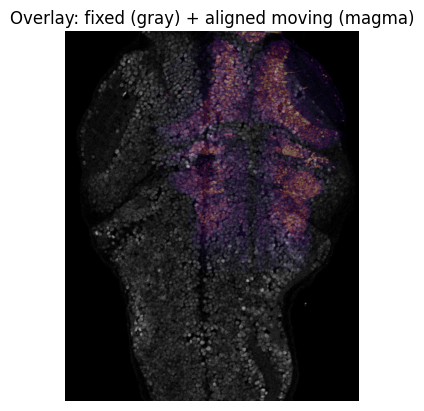

In [63]:

# Apply the composed transforms to the moving image and visualize an overlay.
# This uses bigstream.transform.apply_transform and expects transforms in the format
# produced by the pipeline.

import bigstream.transform as bst

# Compose all transforms into one (affines + optional fields)
composed = bst.compose_transform_list(transform_list, FIXED_SPACING)

# Apply to moving, resampled on the fixed grid
mov_aligned = bst.apply_transform(
    fix, mov,
    FIXED_SPACING, MOVING_SPACING,
    transform_list=[composed],
)

z = fix.shape[0] // 2
plt.figure()
plt.imshow(fix[z], cmap="gray")
plt.imshow(mov_aligned[z], cmap="magma", alpha=0.35)
plt.title("Overlay: fixed (gray) + aligned moving (magma)")
plt.axis("off")
plt.show()


In [17]:
import tifffile

# Convert to something reasonable for saving
mov_aligned_to_save = mov_aligned.astype(np.float32)

tifffile.imwrite(
    "/Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/bigstream/mov_aligned.tif",
    mov_aligned_to_save,
    compression="zlib",  # optional
)

In [ ]:

# Save outputs
import numpy as np
from pathlib import Path

outdir = Path("bigstream_test_output")
outdir.mkdir(exist_ok=True, parents=True)

# Save transforms
for i, t in enumerate(transform_list):
    np.save(outdir / f"transform_{i:02d}.npy", t)

# Save an aligned mid-slice for quick inspection
np.save(outdir / "mov_aligned_mid_slice.npy", mov_aligned[fix.shape[0]//2])

print("Wrote outputs to:", outdir.resolve())
